In [1]:
import os
import scipy
import numpy as np
import pandas as pd
import geopandas as gpd

import seaborn as sns
import matplotlib.pyplot as plt
sns.set_context("paper", font_scale=1.25)

Define paths to lfs data

In [2]:
fpath_lfs = r"C:\eurostat_data"
main_data = r"Yearly Data\YearlyFiles_83_2019\_YearlyFiles"

Read geodata with NUTS regions

In [3]:
gdf = gpd.read_file(os.path.join(fpath_lfs, "felix", "NUTS_RG_03M_2021_4326_LEVL_2", "NUTS_RG_03M_2021_4326_LEVL_2.shp"))

Read preprocessed LFS data (all countries, 2019)

In [4]:
df_merged_all_vars = pd.read_csv(
    os.path.join(fpath_lfs, "felix", "eu_lfs_merged_2019.csv"),
    index_col=0
)

C:\Users\fzaussinger\Miniconda3\envs\lfs\lib\site-packages\IPython\core\interactiveshell.py:3441: DtypeWarning: Columns (6,10,24) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)
C:\Users\fzaussinger\Miniconda3\envs\lfs\lib\site-packages\numpy\lib\arraysetops.py:583: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  mask |= (ar1 == a)


Zoom in on Czech Republic

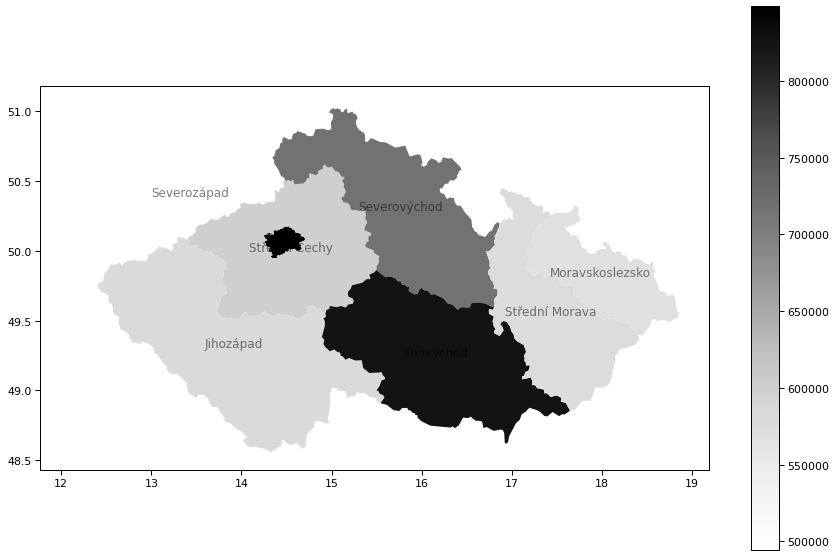

In [5]:
country = "CZ"

df_de = df_merged_all_vars.loc[df_merged_all_vars.COUNTRY == country]

gdf_de = pd.merge(
    df_de.groupby("NUTS_ID").COEFF.sum().reset_index(),
    gdf,
    on="NUTS_ID",
    how="left"
)

gdf_de = gpd.GeoDataFrame(gdf_de)

ax = gdf_de.plot(column="COEFF", figsize=(15, 10), legend=True, cmap="Greys")

gdf_de.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5), axis=1);

#### Estimate absolute and relative employment shares in GBN for NUTS2 regions

In [6]:
df_de_merged_by_nuts = df_de.groupby("NUTS_ID")[["COEFF", "is_brown_abs", "is_green_abs", "is_neutral_abs"]].sum()
df_de_merged_by_nuts

df_de_merged_by_nuts["is_brown_pc"] = df_de_merged_by_nuts.is_brown_abs / df_de_merged_by_nuts.COEFF
df_de_merged_by_nuts["is_neutral_pc"] = df_de_merged_by_nuts.is_neutral_abs / df_de_merged_by_nuts.COEFF
df_de_merged_by_nuts["is_green_pc"] = df_de_merged_by_nuts.is_green_abs / df_de_merged_by_nuts.COEFF

In [7]:
gdf_de_merged_by_nuts = pd.merge(
    gdf.loc[gdf.CNTR_CODE == country],
    df_de_merged_by_nuts,
    on="NUTS_ID",
    how="left"
)

#### Plot

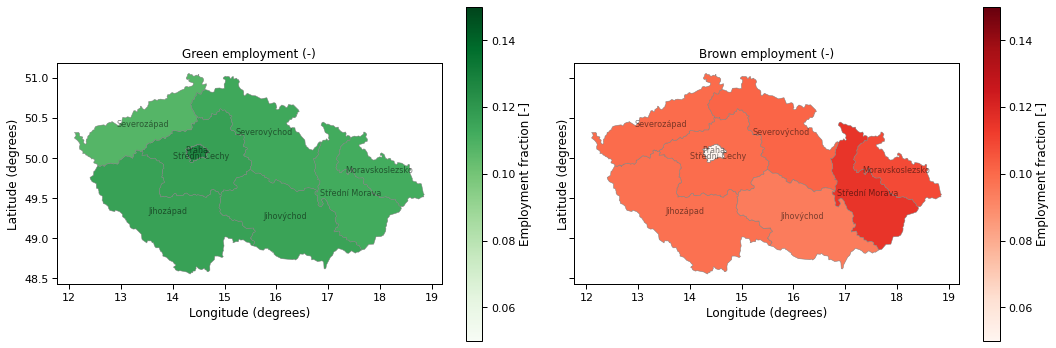

In [8]:
fig, axes = plt.subplots(ncols=2, sharex=True, sharey=True, figsize=(15, 5))

vmin, vmax = 0.05, 0.15
gdf_de_merged_by_nuts.plot(column="is_green_pc", figsize=(10, 5), legend=True, cmap="Greens", vmin=vmin, vmax=vmax, ax=axes[0], legend_kwds={"label": "Employment fraction [-]"}, edgecolor="grey", linewidth=0.5)
gdf_de_merged_by_nuts.plot(column="is_brown_pc", figsize=(10, 5), legend=True, cmap="Reds", vmin=vmin, vmax=vmax, ax=axes[1], legend_kwds={"label": "Employment fraction [-]"}, edgecolor="grey", linewidth=0.5)

axes[0].set_title("Green employment (-)")
axes[1].set_title("Brown employment (-)")

for ax in axes:
    ax.set_xlabel("Longitude (degrees)")
    ax.set_ylabel("Latitude (degrees)")
    gdf_de_merged_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8), axis=1)

plt.tight_layout()

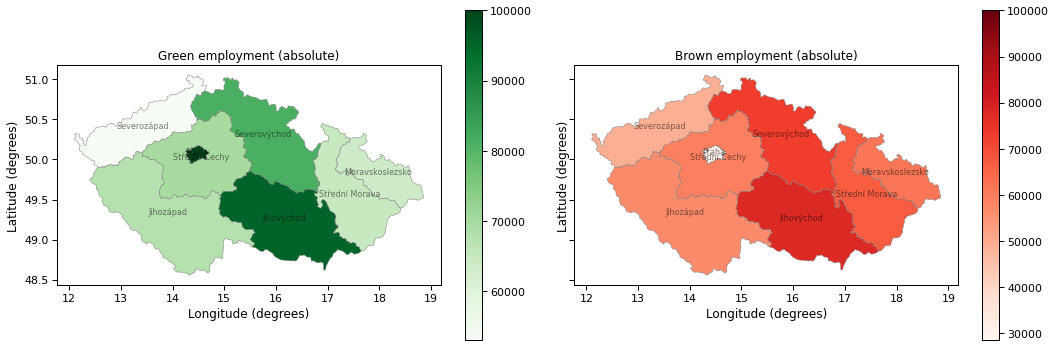

In [9]:
fig, axes = plt.subplots(ncols=2, sharex=True, sharey=True, figsize=(15, 5))

vmax = 100000
gdf_de_merged_by_nuts.plot(column="is_green_abs", figsize=(10, 5), legend=True, cmap="Greens", vmax=vmax, ax=axes[0], edgecolor="grey", linewidth=0.5)
gdf_de_merged_by_nuts.plot(column="is_brown_abs", figsize=(10, 5), legend=True, cmap="Reds", vmax=vmax, ax=axes[1], edgecolor="grey", linewidth=0.5)

axes[0].set_title("Green employment (absolute)")
axes[1].set_title("Brown employment (absolute)")

for ax in axes:
    ax.set_xlabel("Longitude (degrees)")
    ax.set_ylabel("Latitude (degrees)")
    gdf_de_merged_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8), axis=1)

plt.tight_layout()

#### Look at demographic characteristics of at-risk regions

- Males more concentrated in brown occupations, but also in green occupations.
- Females mostly in neutral occupations

,is_brown,is_green,is_neutral
SEX,,,
1,0.134272,0.152624,0.713104
2,0.051007,0.066693,0.882300


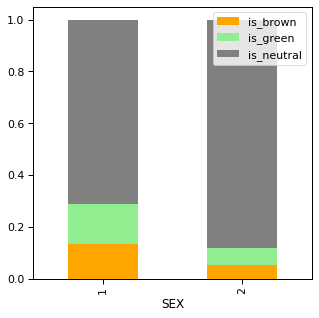

In [10]:
colors = ["orange", "lightgreen", "grey"]
df_de.groupby("SEX")[["is_brown", "is_green", "is_neutral"]].mean().plot.bar(stacked=True, figsize=(5, 5), color=colors)
df_de.groupby("SEX")[["is_brown", "is_green", "is_neutral"]].mean()

Males
- share of brown employment drops with Age 65
- share of green employment increases over age

<AxesSubplot:xlabel='SEX,AGE'>

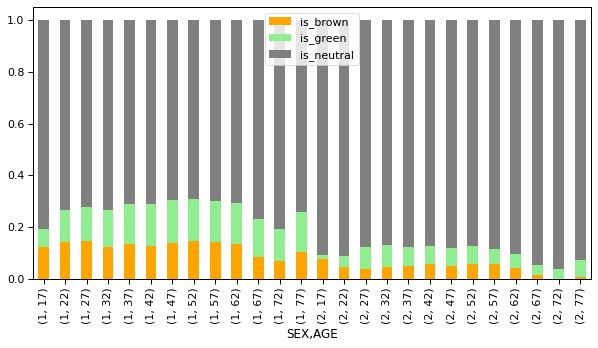

In [11]:
df_de.groupby(["SEX", "AGE"])[["is_brown", "is_green", "is_neutral"]].mean().plot.bar(stacked=True, figsize=(10,5), color=colors)

#### Skill distribution
- brown occs low to mid skilled
- green occs high skilled

<AxesSubplot:xlabel='HATLEV1D'>

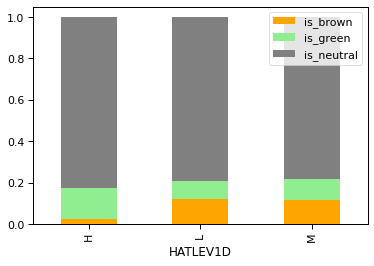

In [12]:
df_de.groupby("HATLEV1D")[["is_brown", "is_green", "is_neutral"]].mean()
df_de.groupby("HATLEV1D")[["is_brown", "is_green", "is_neutral"]].mean().plot.bar(stacked=True,  color=colors)

#### Full vs part time
- 1: full time, 2: part time
- higher share of green part time jobs than brown part time jobs

<AxesSubplot:xlabel='FTPT'>

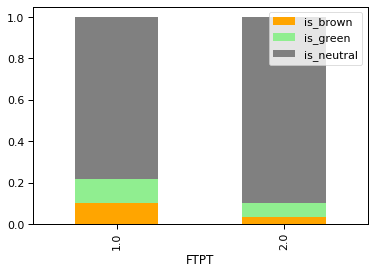

In [13]:
df_de.groupby("FTPT")[["is_brown", "is_green", "is_neutral"]].mean()
df_de.groupby("FTPT")[["is_brown", "is_green", "is_neutral"]].mean().plot.bar(stacked=True, color=colors)

#### Zoom in on coal-related ISCO 3-digit groups
- of 119 unique isco 3d groups in total 5 are related to mining
- use NACE sections to distinguish between manufacturing etc. and mining activities
- 229 observations form the basis of the analysis

#### Approach for classifying coal-related jobs based on ISCO and NACE

Relevant sectors:
- Electricity, Gas, Steam and Air Conditioning Supply
- Mining and Quarrying

Relevant ISCO groups:
- 'Manufacturing, mining, construction, and distribution managers'
- 'Mining, manufacturing and construction supervisors'
- 'Mining and mineral processing plant operators'
- 'Labourers in mining, construction, manufacturing and transport'
- 'Mining and construction labourers'

In [14]:
df_de_merged_mining = df_de.loc[df_de.mining == True]

Distribution of employees in mining-related occupation groups by industry sector

In [15]:
df_de_merged_mining.groupby(["NACE1D_label"]).COEFF.sum()

NACE1D_label
Electricity, Gas, Steam and Air Conditioning Supply    3404.71
Mining and Quarrying                                   7077.79
Name: COEFF, dtype: float64

In [16]:
df_de_merged_mining.groupby(["NACE1D_label", "ISCO3D_label"]).COEFF.sum()

NACE1D_label                                         ISCO3D_label                                                  
Electricity, Gas, Steam and Air Conditioning Supply  Manufacturing, mining, construction, and distribution managers    2006.10
                                                     Mining, manufacturing and construction supervisors                1398.61
Mining and Quarrying                                 Mining and construction labourers                                  355.58
                                                     Mining and mineral processing plant operators                     5687.75
                                                     Mining, manufacturing and construction supervisors                1034.46
Name: COEFF, dtype: float64

In [17]:
dict(zip(df_de_merged_mining.ISCO3D_label.unique(), df_de_merged_mining.ISCO3D.unique()))

{'Mining, manufacturing and construction supervisors': 312,
 'Mining and mineral processing plant operators': 811,
 'Mining and construction labourers': 931,
 'Manufacturing, mining, construction, and distribution managers': 132}

### Spatial distribution of mining jobs

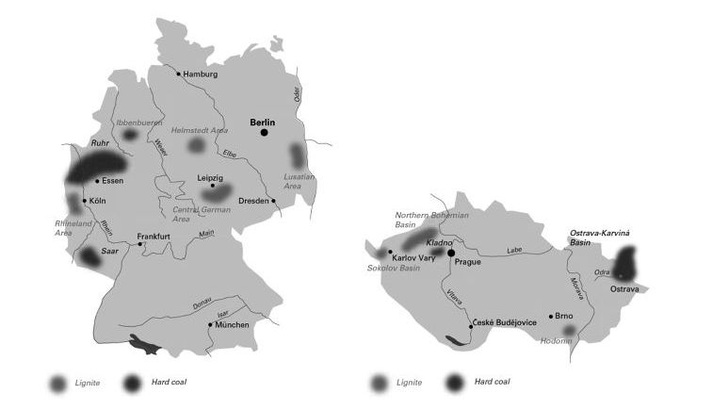

#### By sector

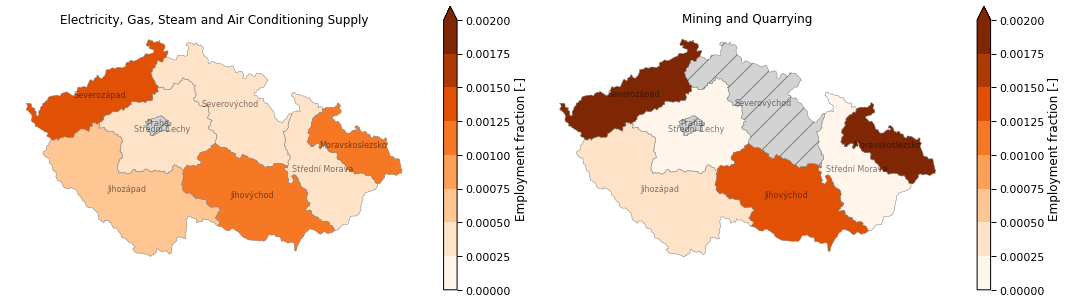

In [18]:
fig, axes = plt.subplots(ncols=2, figsize=(15, 5), sharex=True, sharey=True)
axes = axes.flatten()

for i, nace_group in enumerate(df_de_merged_mining.NACE1D_label.unique()):
    subset = df_de_merged_mining.loc[df_de_merged_mining.NACE1D_label == nace_group]

    subset_by_nuts = subset.groupby("NUTS_ID")[["COEFF", "is_brown_abs", "is_green_abs", "is_neutral_abs"]].sum()
    subset_by_nuts["COEFF_mining_pc"] = subset_by_nuts.COEFF / df_de_merged_by_nuts.COEFF
    
    gdf_subset_by_nuts = pd.merge(
        gdf.loc[gdf.CNTR_CODE == country],
        subset_by_nuts,
        on="NUTS_ID",
        how="left"
    )

    ax = axes[i]
    gdf_subset_by_nuts.plot(column="COEFF_mining_pc", legend=True, cmap=plt.get_cmap("Oranges", 8), ax = ax, vmin=0, legend_kwds={"label": "Employment fraction [-]", "fraction": 0.03, "extend":"max"}, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"}, vmax=0.002, edgecolor="grey", linewidth=0.5)
    gdf_subset_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8), axis=1)
    ax.set_title(nace_group) 
    
    ax.axis('off')
    
plt.tight_layout()

plt.savefig(
    os.path.join(fpath_lfs, "felix", "figures", "coal_employment_rel_by_sector_cz_2019.png"),
    dpi=300,
    bbox_inches="tight"
)

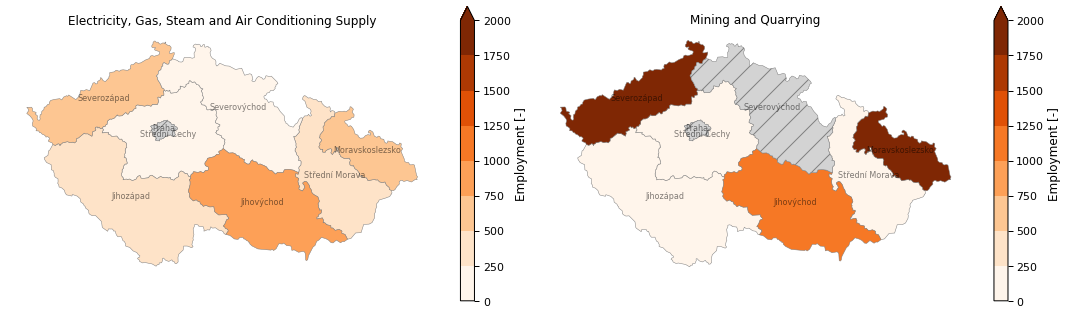

In [19]:
fig, axes = plt.subplots(ncols=2, figsize=(15, 5), sharex=True, sharey=True)
axes = axes.flatten()

for i, nace_group in enumerate(df_de_merged_mining.NACE1D_label.unique()):
    subset = df_de_merged_mining.loc[df_de_merged_mining.NACE1D_label == nace_group]

    subset_by_nuts = subset.groupby("NUTS_ID")[["COEFF", "is_brown_abs", "is_green_abs", "is_neutral_abs"]].sum()
    #subset_by_nuts["COEFF_mining_pc"] = subset_by_nuts.COEFF / df_de_merged_by_nuts.COEFF
    
    gdf_subset_by_nuts = pd.merge(
        gdf.loc[gdf.CNTR_CODE == country],
        subset_by_nuts,
        on="NUTS_ID",
        how="left"
    )

    ax = axes[i]
    gdf_subset_by_nuts.plot(column="COEFF", legend=True, cmap=plt.get_cmap("Oranges", 8), ax = ax, vmin=0, legend_kwds={"label": "Employment [-]", "fraction": 0.03, "extend": "max"}, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"}, vmax=2000, edgecolor="grey", linewidth=0.5)
    gdf_subset_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8), axis=1)

    ax.set_title(nace_group) 
    
    ax.axis('off')
    
plt.tight_layout()

plt.savefig(
    os.path.join(fpath_lfs, "felix", "figures", "coal_employment_abs_by_sector_cz_2019.png"),
    dpi=300,
    bbox_inches="tight"
)

#### By occupation

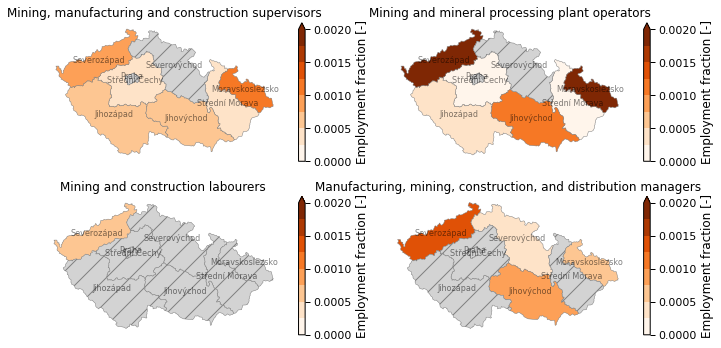

In [20]:
fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(10, 5), sharex=True, sharey=True)
axes = axes.flatten()

for i, group in enumerate(df_de_merged_mining.ISCO3D_label.unique()):
    subset = df_de_merged_mining.loc[df_de_merged_mining.ISCO3D_label == group]

    subset_by_nuts = subset.groupby("NUTS_ID")[["COEFF", "is_brown_abs", "is_green_abs", "is_neutral_abs"]].sum()
    subset_by_nuts["COEFF_mining_pc"] = subset_by_nuts.COEFF / df_de_merged_by_nuts.COEFF
    
    gdf_subset_by_nuts = pd.merge(
        gdf.loc[gdf.CNTR_CODE == country],
        subset_by_nuts,
        on="NUTS_ID",
        how="left"
    )

    ax = axes[i]
    gdf_subset_by_nuts.plot(column="COEFF_mining_pc", legend=True, cmap=plt.get_cmap("Oranges", 8), ax = ax, vmin=0, legend_kwds={"label": "Employment fraction [-]", "fraction": 0.03, "extend":"max"}, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"}, vmax=0.002, edgecolor="grey", linewidth=0.5)
    gdf_subset_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8), axis=1)
    ax.set_title(group) 
    
    ax.axis('off')
    
plt.tight_layout()

plt.savefig(
    os.path.join(fpath_lfs, "felix", "figures", "coal_employment_rel_by_occupation_cz_2019.png"),
    dpi=300,
    bbox_inches="tight"
)

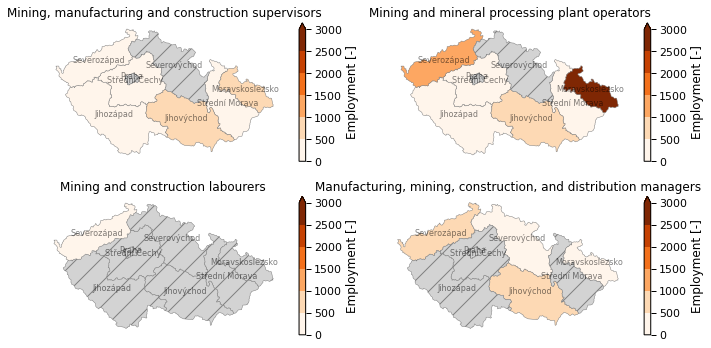

In [21]:
fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(10, 5), sharex=True, sharey=True)
axes = axes.flatten()

for i, group in enumerate(df_de_merged_mining.ISCO3D_label.unique()):
    subset = df_de_merged_mining.loc[df_de_merged_mining.ISCO3D_label == group]

    subset_by_nuts = subset.groupby("NUTS_ID")[["COEFF", "is_brown_abs", "is_green_abs", "is_neutral_abs"]].sum()
    subset_by_nuts["COEFF_mining_pc"] = subset_by_nuts.COEFF / df_de_merged_by_nuts.COEFF
    
    gdf_subset_by_nuts = pd.merge(
        gdf.loc[gdf.CNTR_CODE == country],
        subset_by_nuts,
        on="NUTS_ID",
        how="left"
    )

    ax = axes[i]
    gdf_subset_by_nuts.plot(column="COEFF", legend=True, cmap=plt.get_cmap("Oranges", 6), ax = ax, vmin=0, legend_kwds={"label": "Employment [-]", "fraction": 0.03, "extend":"max"}, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"}, edgecolor="grey", linewidth=0.5, vmax=3000)
    gdf_subset_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8), axis=1)
    ax.set_title(group) 
    
    ax.axis('off')
    
plt.tight_layout()

plt.savefig(
    os.path.join(fpath_lfs, "felix", "figures", "coal_employment_abs_by_occupation_cz_2019.png"),
    dpi=300,
    bbox_inches="tight"
)

#### Combined

In [22]:
df_de_merged_mining_by_nuts = df_de_merged_mining.groupby("NUTS_ID")[["COEFF", "is_brown_abs", "is_green_abs", "is_neutral_abs"]].sum()
df_de_merged_mining_by_nuts["COEFF_mining_pc"] = df_de_merged_mining_by_nuts.COEFF / df_de_merged_by_nuts.COEFF

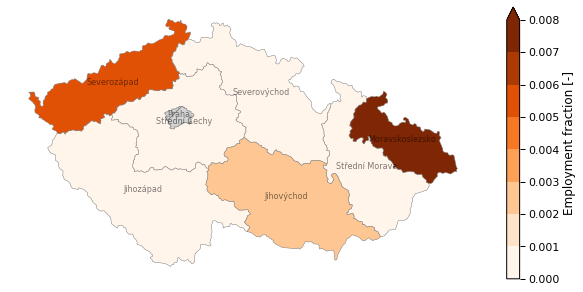

In [23]:
gdf_de_merged_mining_by_nuts = pd.merge(
    gdf.loc[gdf.CNTR_CODE == country],
    df_de_merged_mining_by_nuts,
    on="NUTS_ID",
    how="left"
)


ax = gdf_de_merged_mining_by_nuts.plot(column="COEFF_mining_pc", figsize=(10, 5), legend=True, cmap=plt.get_cmap("Oranges", 8), vmin=0, vmax=0.008, legend_kwds={"label": "Employment fraction [-]", "fraction": 0.03, "extend":"max"}, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"}, edgecolor="grey", linewidth=0.5)
gdf_de_merged_mining_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8), axis=1)

ax.axis('off')

plt.savefig(
    os.path.join(fpath_lfs, "felix", "figures", "coal_employment_rel_cz_2019.png"),
    dpi=300,
    bbox_inches="tight"
)

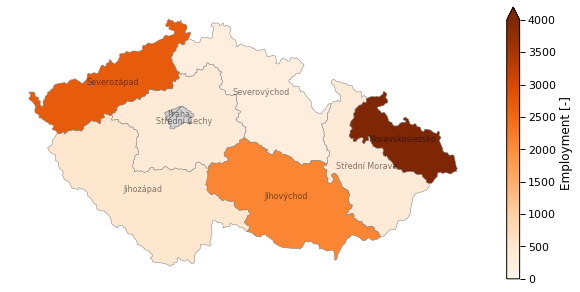

In [24]:
gdf_de_merged_mining_by_nuts = pd.merge(
    gdf.loc[gdf.CNTR_CODE == country],
    df_de_merged_mining_by_nuts,
    on="NUTS_ID",
    how="left"
)


ax = gdf_de_merged_mining_by_nuts.plot(column="COEFF", figsize=(10, 5), legend=True, cmap="Oranges", vmin=0, vmax=4000, legend_kwds={"label": "Employment [-]", "fraction": 0.03, "extend":"max"}, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"}, edgecolor="grey", linewidth=0.5)
gdf_de_merged_mining_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8), axis=1)

ax.axis('off')

plt.savefig(
    os.path.join(fpath_lfs, "felix", "figures", "coal_employment_abs_cz_2019.png"),
    dpi=300,
    bbox_inches="tight"
)

#### Demographic characteristics of mining-related jobs

Mining occupation older on average

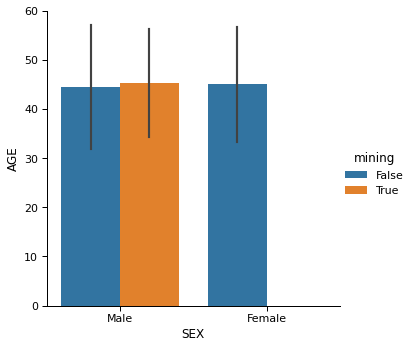

In [25]:
g = sns.catplot(
    x="SEX",
    y="AGE",
    hue="mining",
    kind="bar",
    ci="sd",
    data=df_de
)

g.set_xticklabels(["Male", "Female"])

SEX
1    1.0
Name: COEFF, dtype: float64

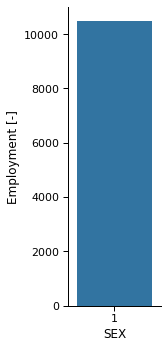

In [26]:

g = sns.catplot(
    x="SEX",
    y="COEFF",
    kind="bar",
    estimator=np.sum,
    ci=None,
    data=df_de[df_de.mining],
    height=5,
    aspect=0.5
)

#g.set_xticklabels(["Male", "Female"])
g.axes[0][0].set_ylabel("Employment [-]")

df_de[df_de.mining].groupby("SEX").COEFF.sum() / df_de[df_de.mining].groupby("SEX").COEFF.sum().sum()

Mining occupations seem to earn higher wages across all skill levels (8ung: earnings are self-reported!!)

In [27]:
df_de.groupby("mining")["HATLEV1D"].value_counts()

mining  HATLEV1D
False   M           12536
        H            3853
        L             823
True    M              31
        H               5
        L               3
Name: HATLEV1D, dtype: int64

Text(36.17070105820106, 0.5, 'Employment [-]')

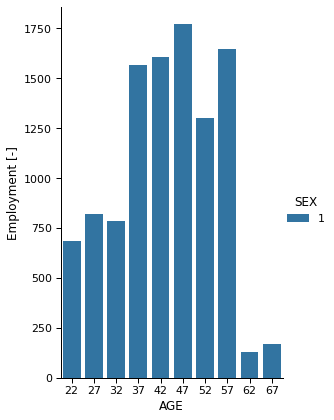

In [28]:
g = sns.catplot(
    x="AGE",
    y="COEFF",
    hue="SEX",
    kind="bar",
    estimator=np.sum,
    ci=None,
    data=df_de[df_de.mining],
    height=6,
    aspect=0.7
)

g.axes[0][0].set_ylabel("Employment [-]")

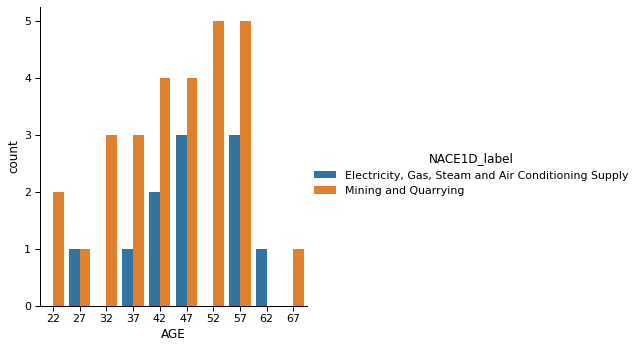

In [29]:
g = sns.catplot(
    x="AGE",
    hue="NACE1D_label",
    kind="count",
    #estimator=np.mean,
    ci=None,
    data=df_de_merged_mining
)